# Fake News Detection Model Comparison
This notebook trains multiple machine learning models and selects the best one.

In [2]:
!pip install pandas scikit-learn numpy joblib matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.7 MB 7.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.7 MB 6.9 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.7 MB 4.5 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.7 MB 3.6 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.7 MB 3.2 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.7 MB 3.0 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.7 MB 2.9 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.7 MB 2.9 MB/s eta 0:00:02
   ------------------------ ---------

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\HP\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\pandas\\tests\\frame\\methods\\test_between_time.py'
Check the permissions.


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas-3.0.1-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
Using cached pandas-3.0.1-cp312-cp312-win_amd64.whl (9.7 MB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt

In [4]:
fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')

fake['label'] = 0
true['label'] = 1

data = pd.concat([fake, true])
data['content'] = data['title'] + ' ' + data['text']

In [5]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
X = vectorizer.fit_transform(data['content'])
y = data['label']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'SVM': LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(name, 'Accuracy:', acc)

Logistic Regression Accuracy: 0.9865256124721603
Naive Bayes Accuracy: 0.9324053452115812
Random Forest Accuracy: 0.9965478841870824
SVM Accuracy: 0.9952115812917595


In [8]:
best_model_name = max(results, key=results.get)
print('Best Model:', best_model_name)

Best Model: Random Forest


In [9]:
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

joblib.dump(best_model, 'best_fake_news_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

print('Model saved')

Model saved


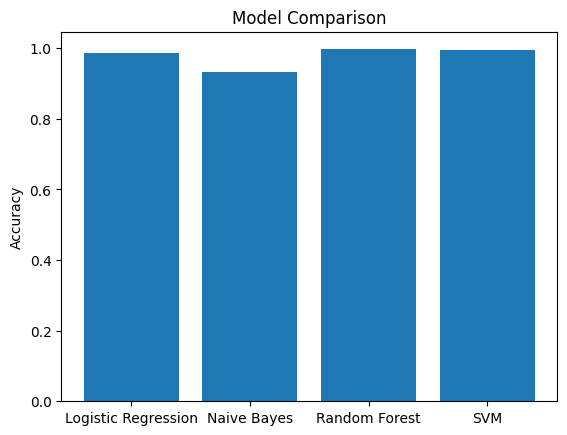

In [10]:
names = list(results.keys())
scores = list(results.values())

plt.bar(names, scores)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.show()